# 05 — Experiment Comparison

Load `metrics.json` from multiple experiment output directories and compare
final loss, best validation loss, and convergence speed side-by-side.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# ── Point to experiment output directories ───────────────────────────────
# Each entry: (display_name, path_to_metrics_json)
experiments = [
    ('exp_001_baseline',     '../outputs/metrics.json'),
    # ('exp_002_bigger_model', '../outputs/exp_002/metrics.json'),
]

records = []
for name, path in experiments:
    p = Path(path)
    if not p.exists():
        print(f'MISSING: {p}')
        continue
    with open(p) as f:
        m = json.load(f)
    records.append({
        'name': name,
        'best_val_loss': m['best_val_loss'],
        'final_train_loss': m['train_losses'][-1] if m['train_losses'] else None,
        'eval_points': len(m['train_losses']),
        '_metrics': m,
    })

df = pd.DataFrame([{k: v for k, v in r.items() if k != '_metrics'} for r in records])
df

,name,best_val_loss,final_train_loss,eval_points
0,exp_001_baseline,2.392057,2.389912,39


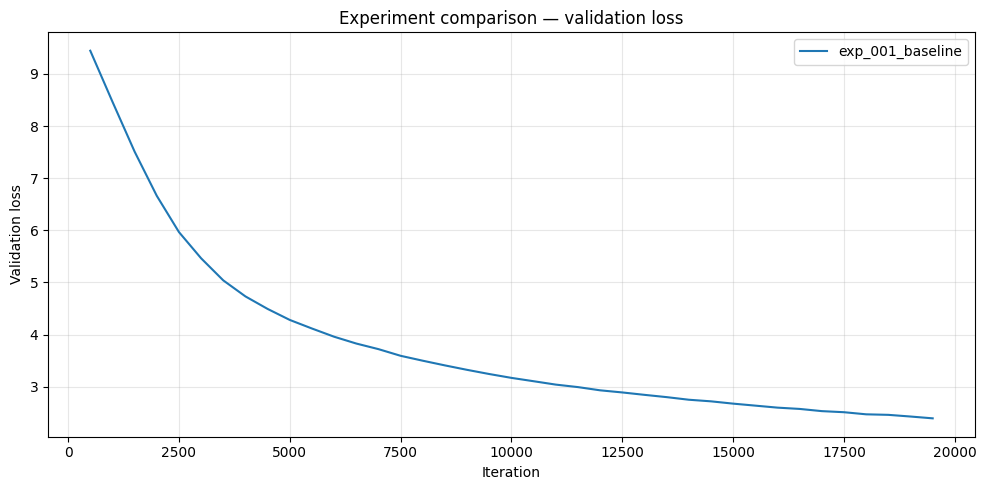

In [3]:
# ── Overlay validation loss curves ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for r in records:
    m = r['_metrics']
    if not m['val_losses']:
        continue
    steps = [i * m['eval_interval'] for i in range(1, len(m['val_losses']) + 1)]
    ax.plot(steps, m['val_losses'], label=r['name'])

ax.set_xlabel('Iteration')
ax.set_ylabel('Validation loss')
ax.set_title('Experiment comparison — validation loss')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()